In [1]:
import matplotlib as mpl

# Increase tick label font sizes and tick length/width globally for all plots
mpl.rcParams.update({
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "xtick.minor.size": 4,
    "ytick.minor.size": 4,
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
    "xtick.minor.width": 1.0,
    "ytick.minor.width": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
})

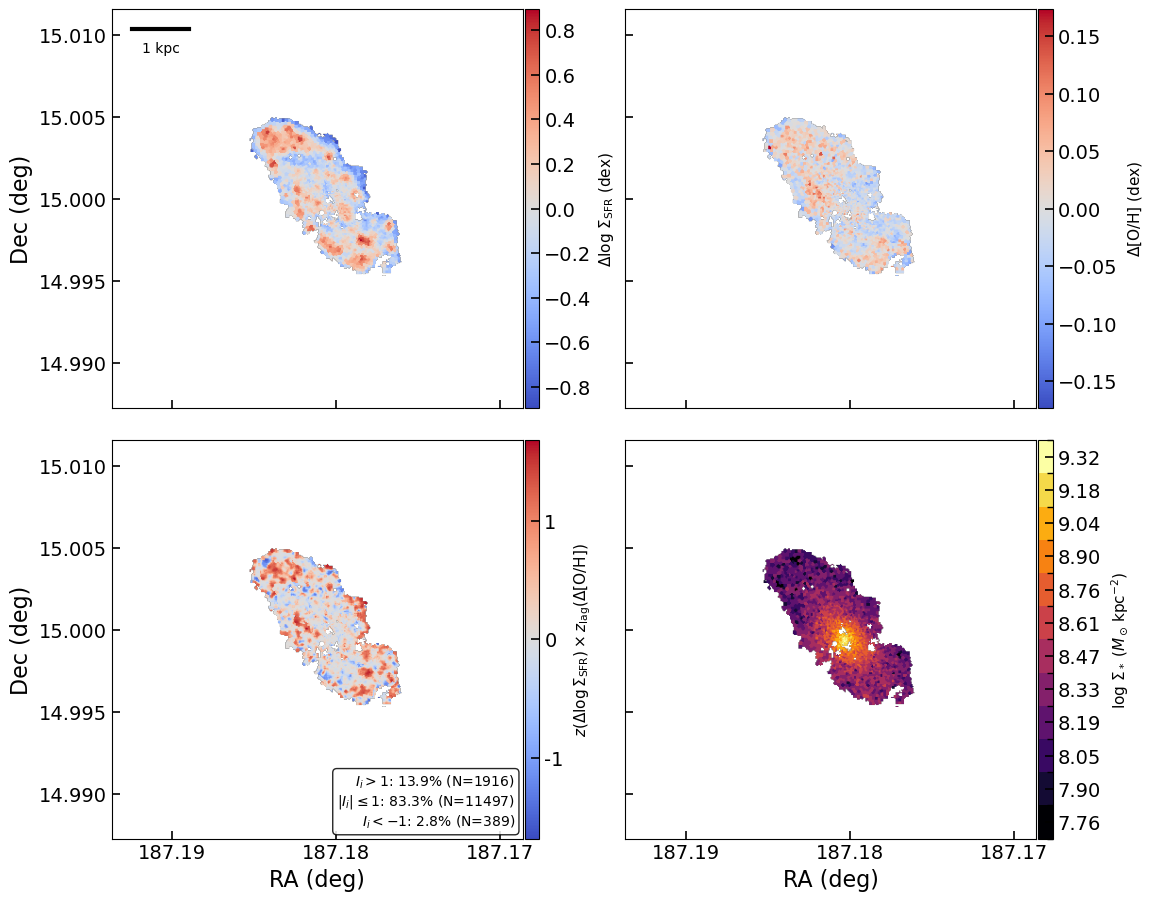

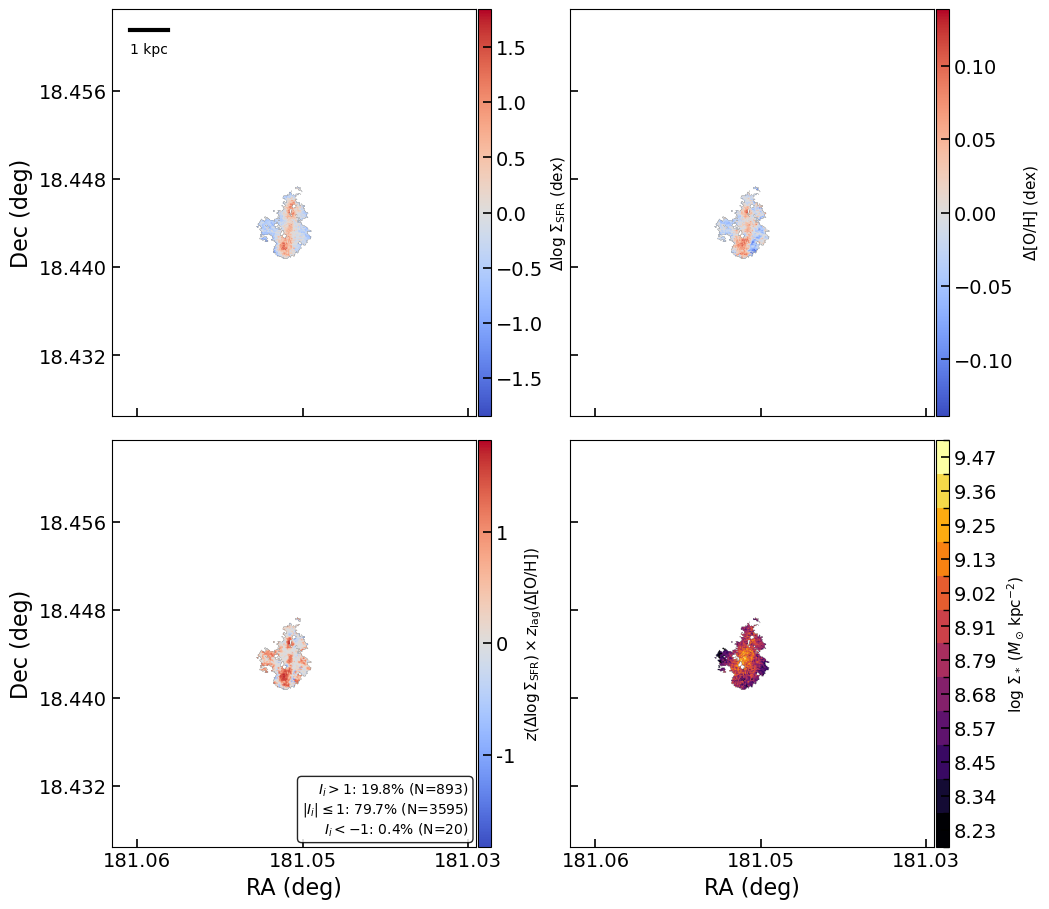

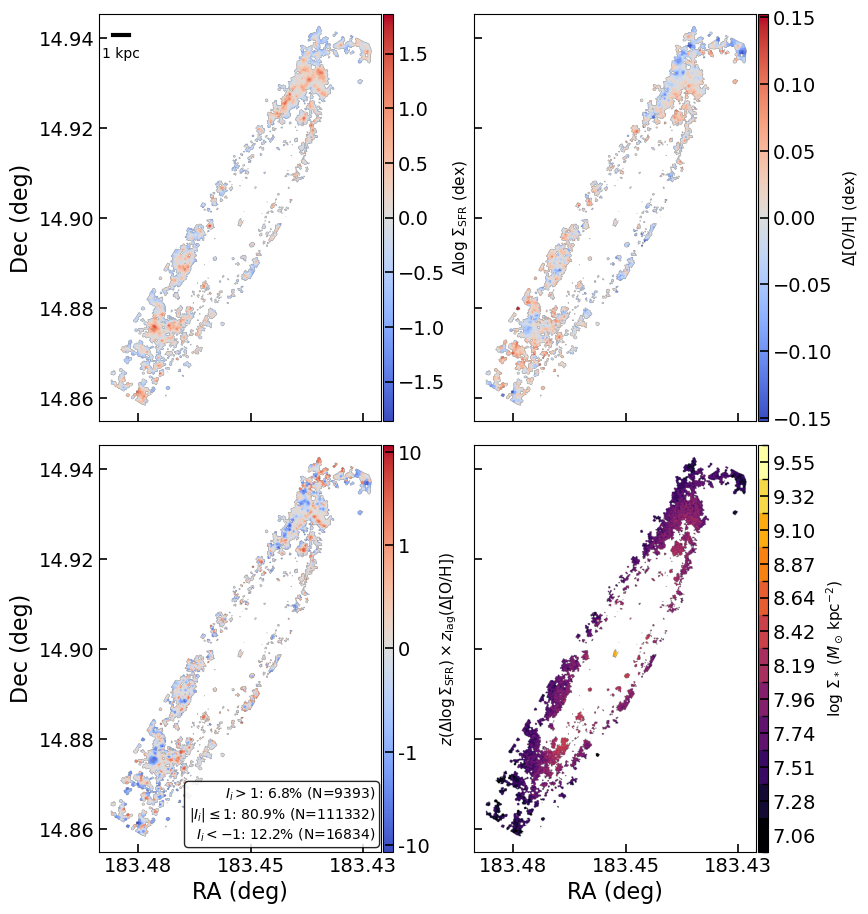

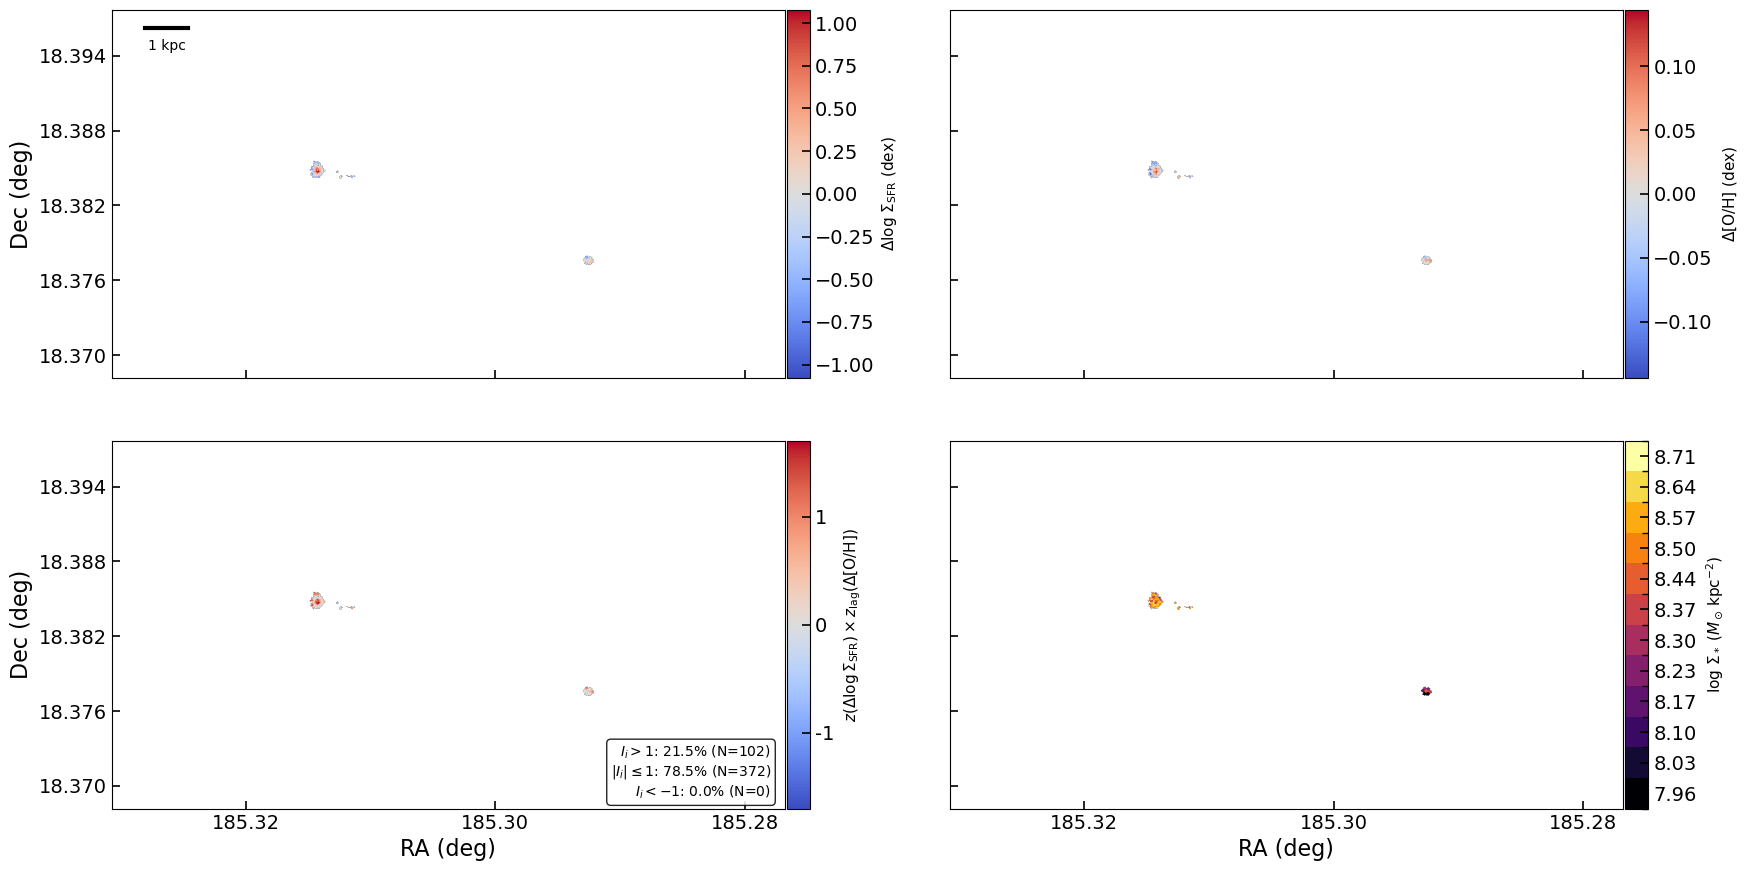

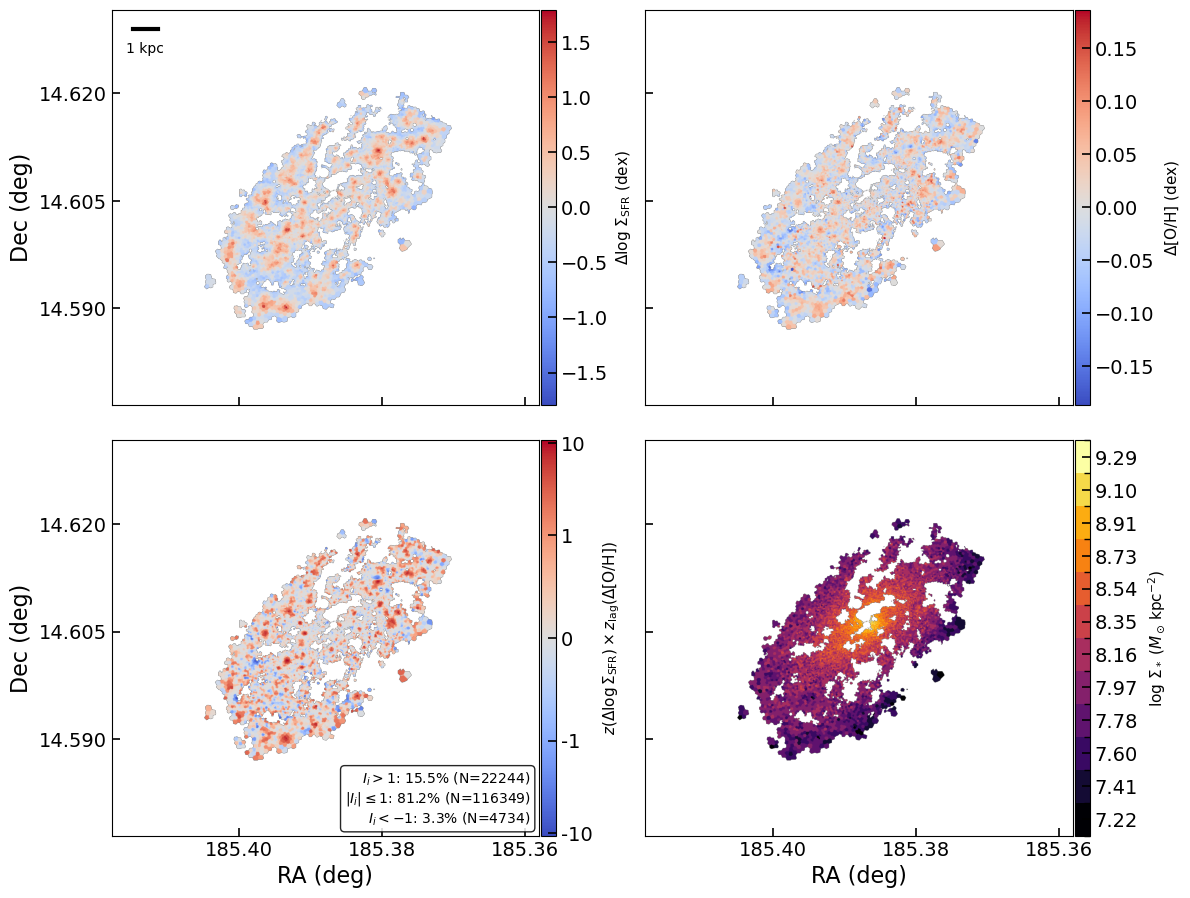

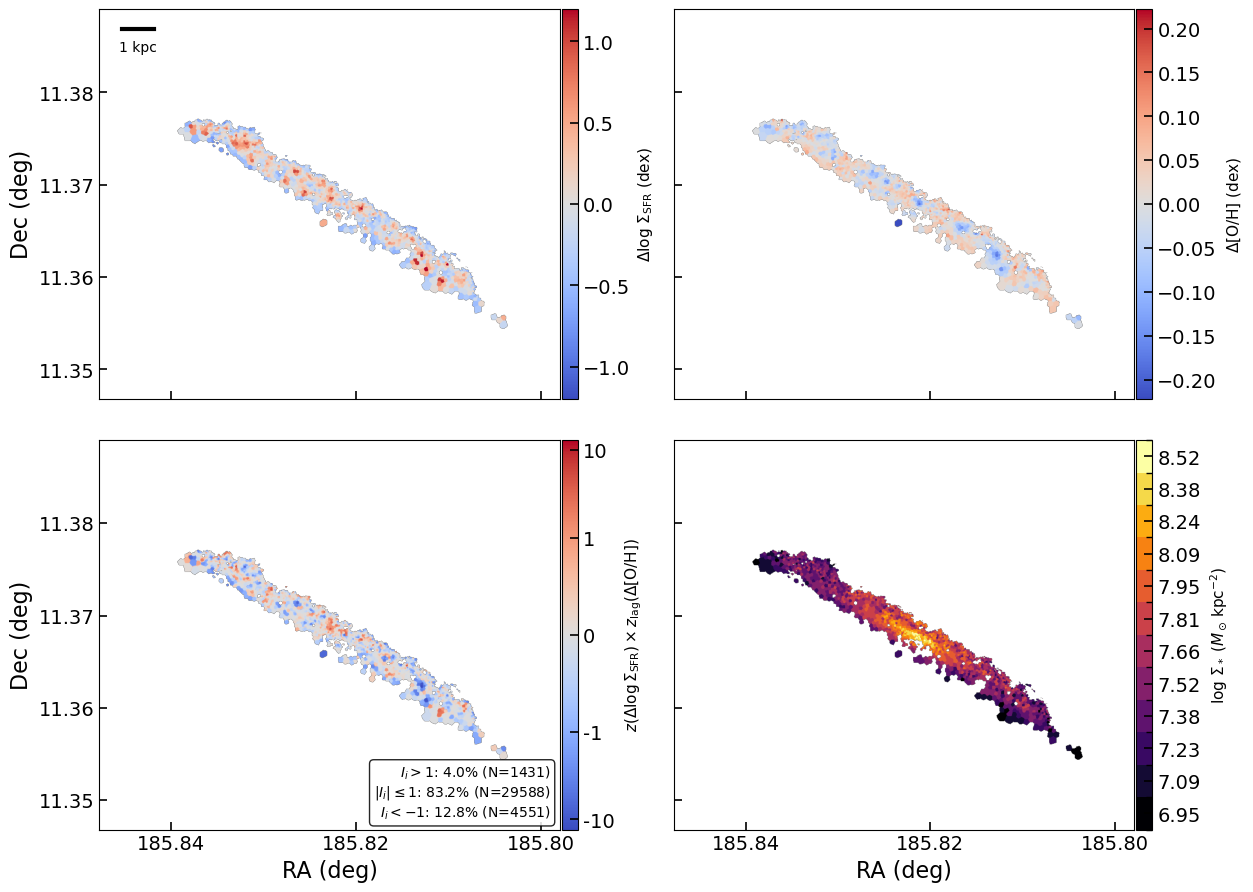

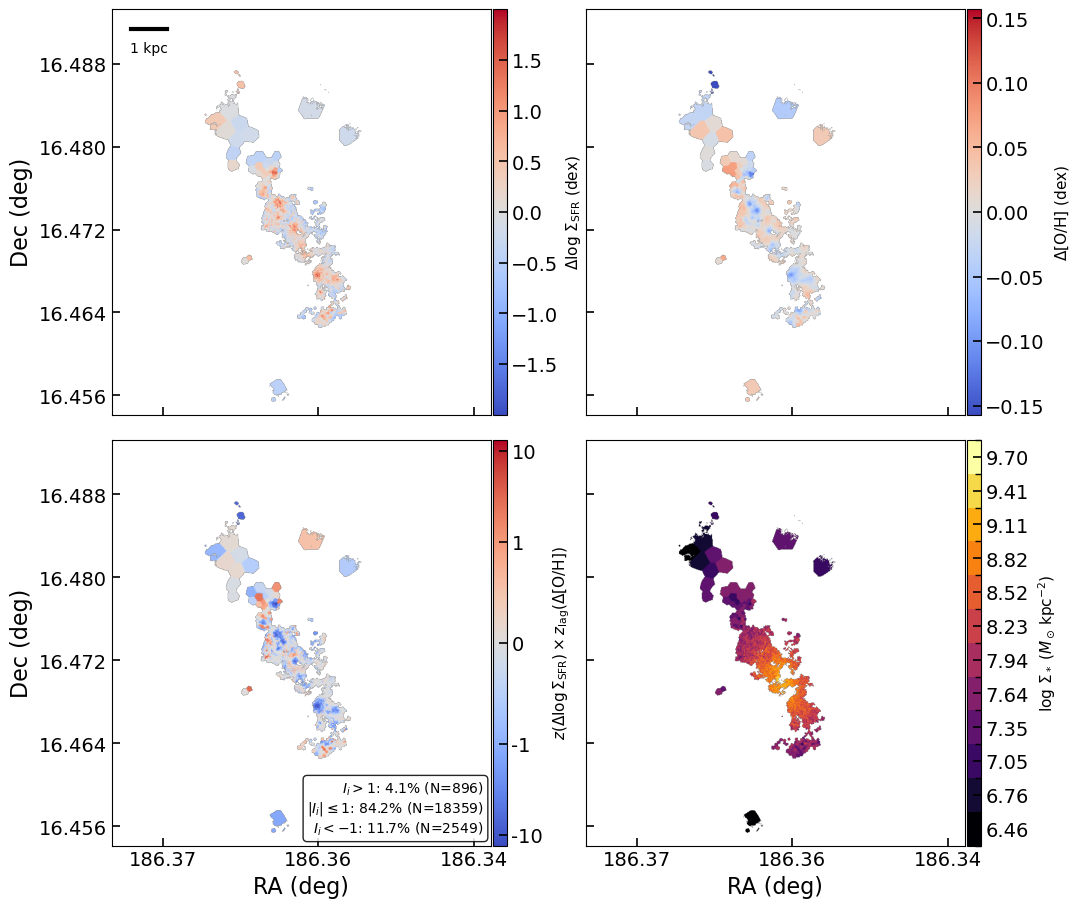

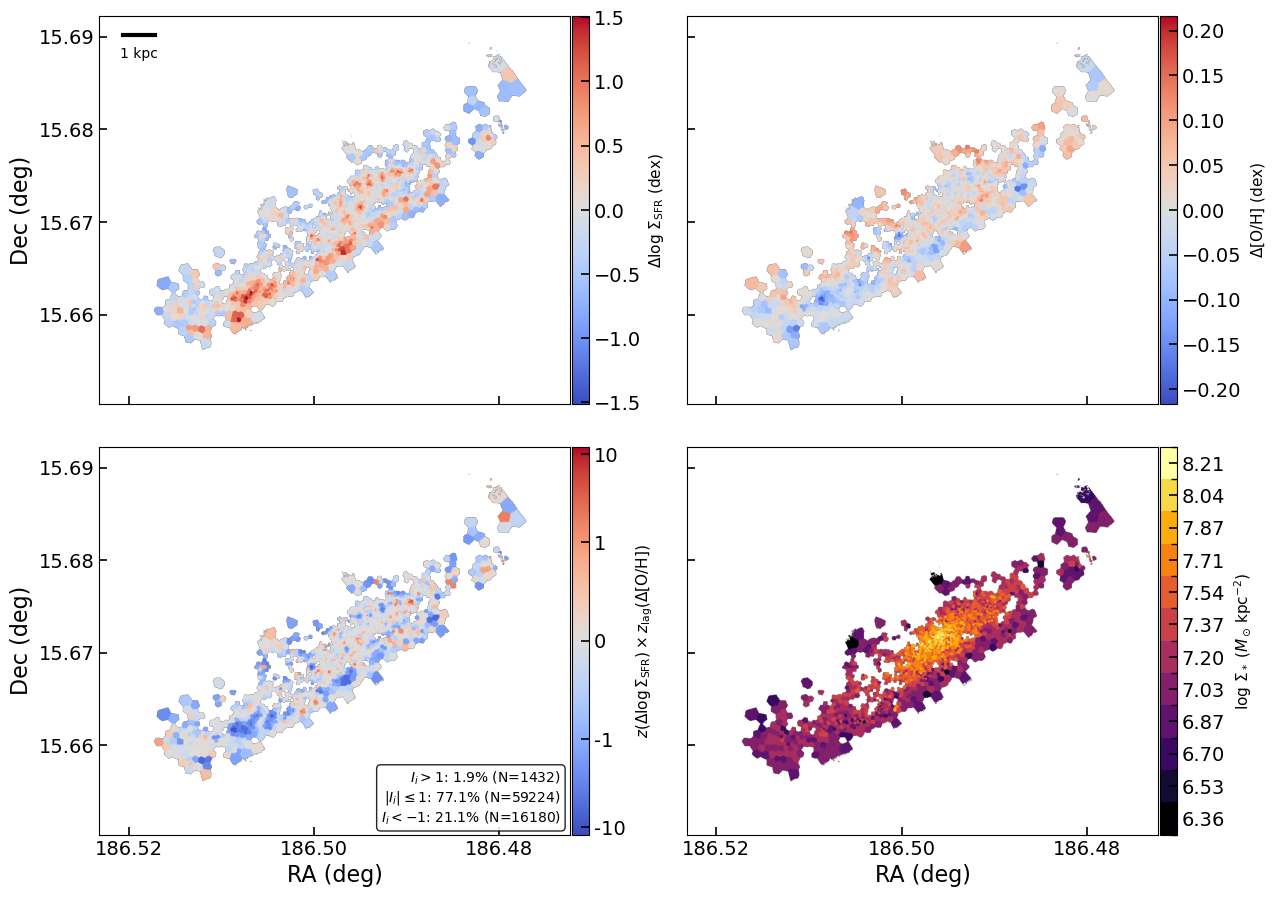

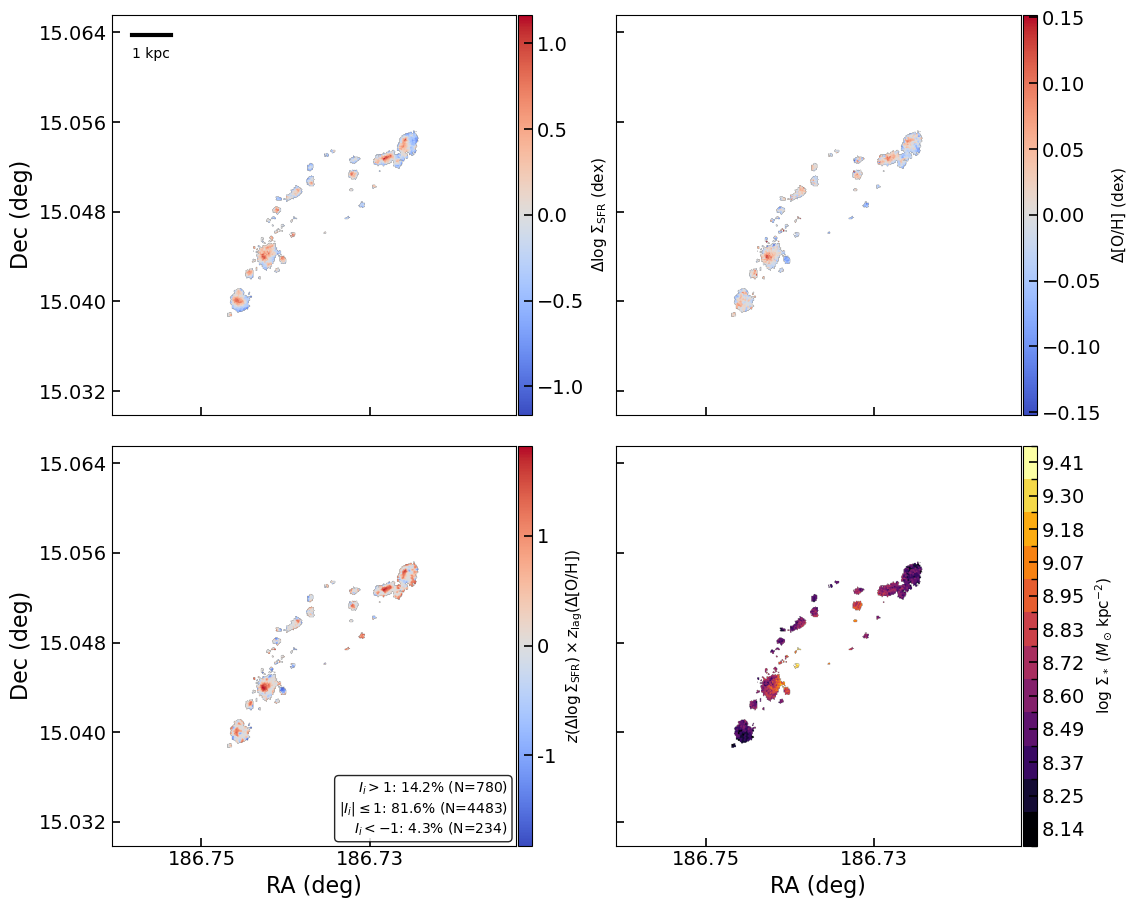

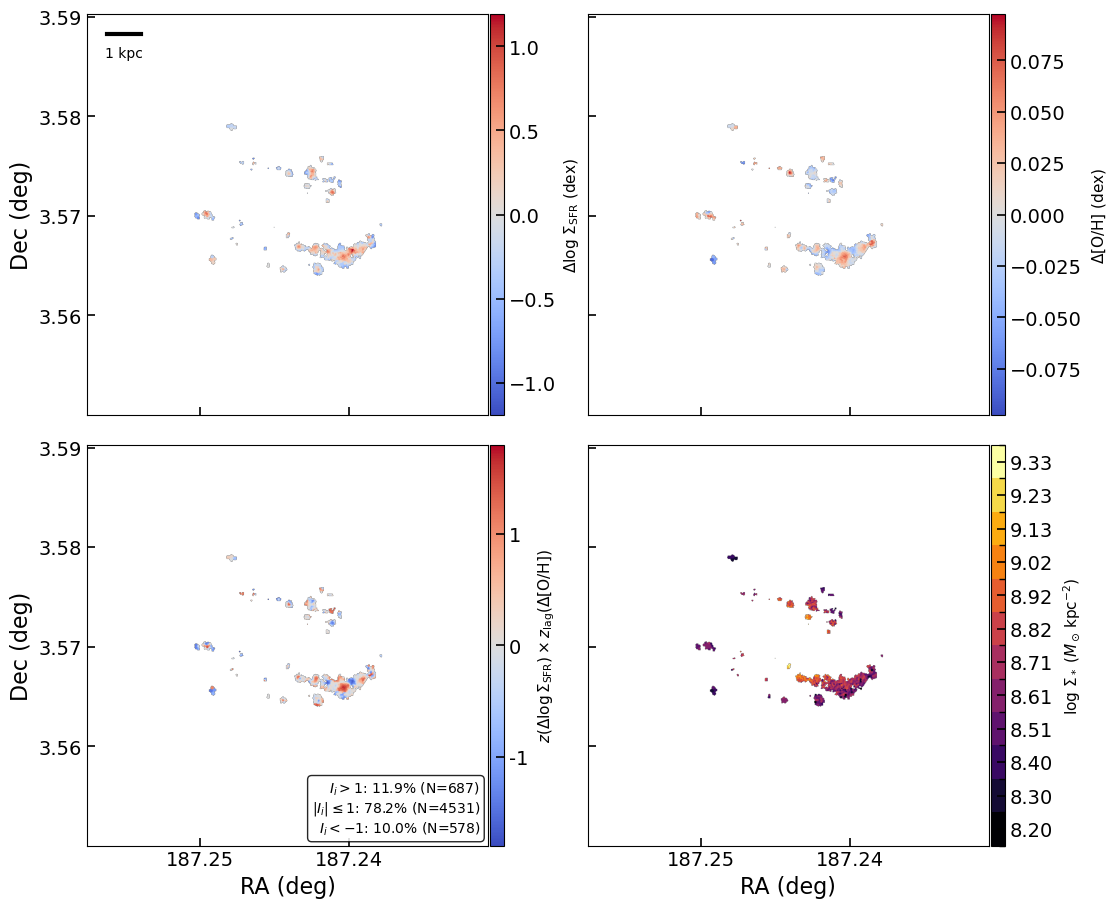

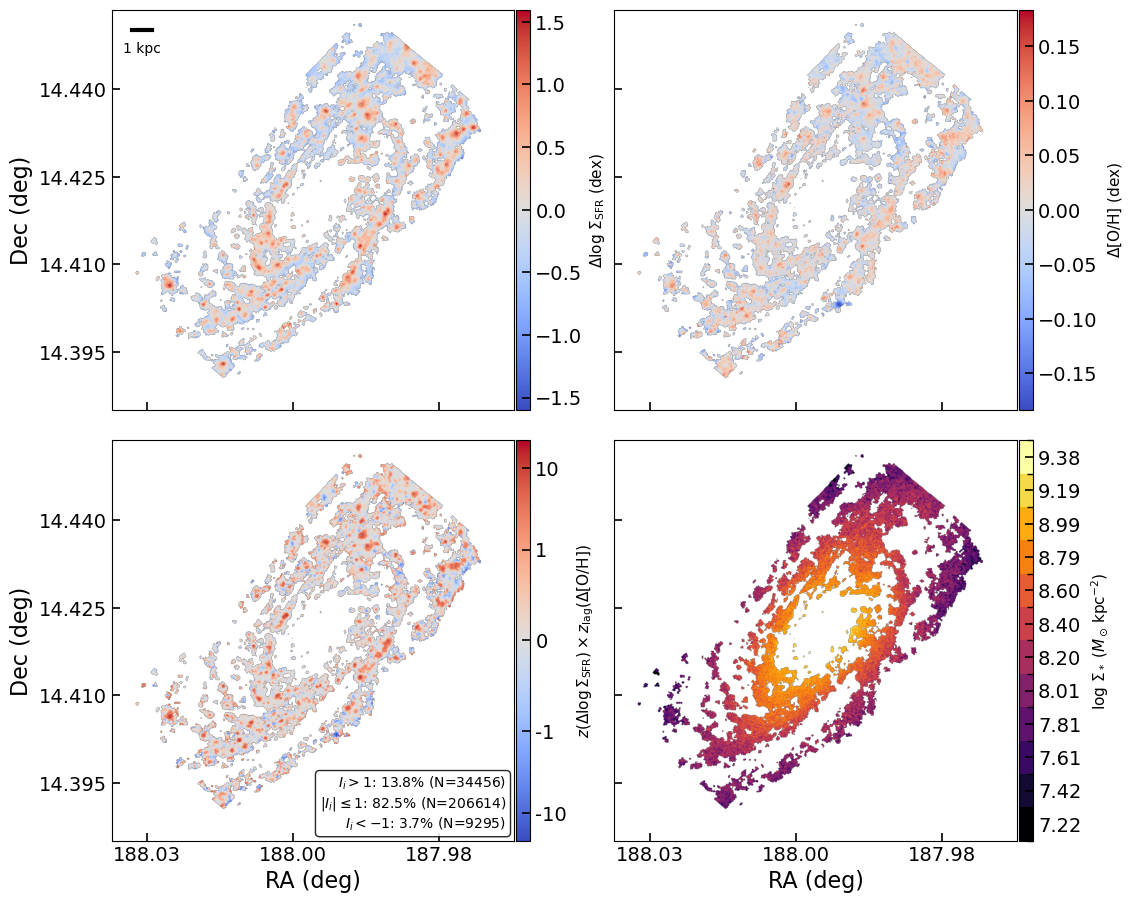

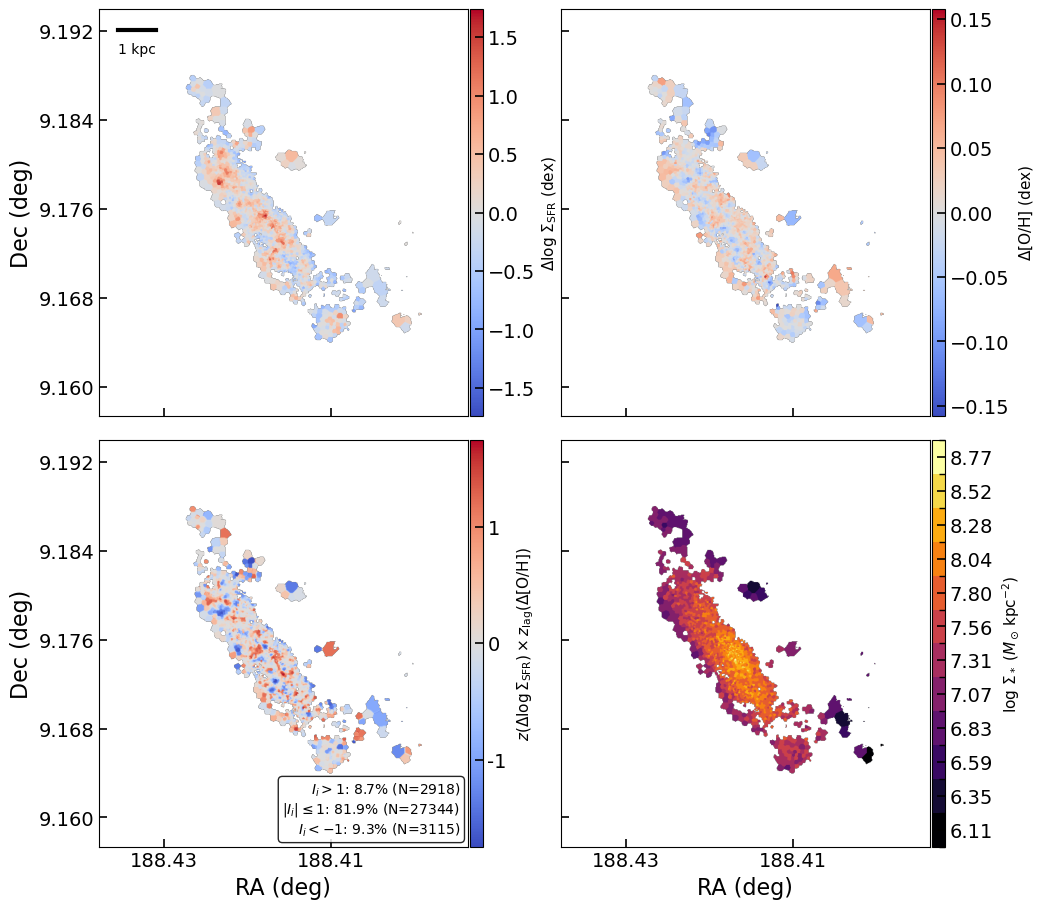

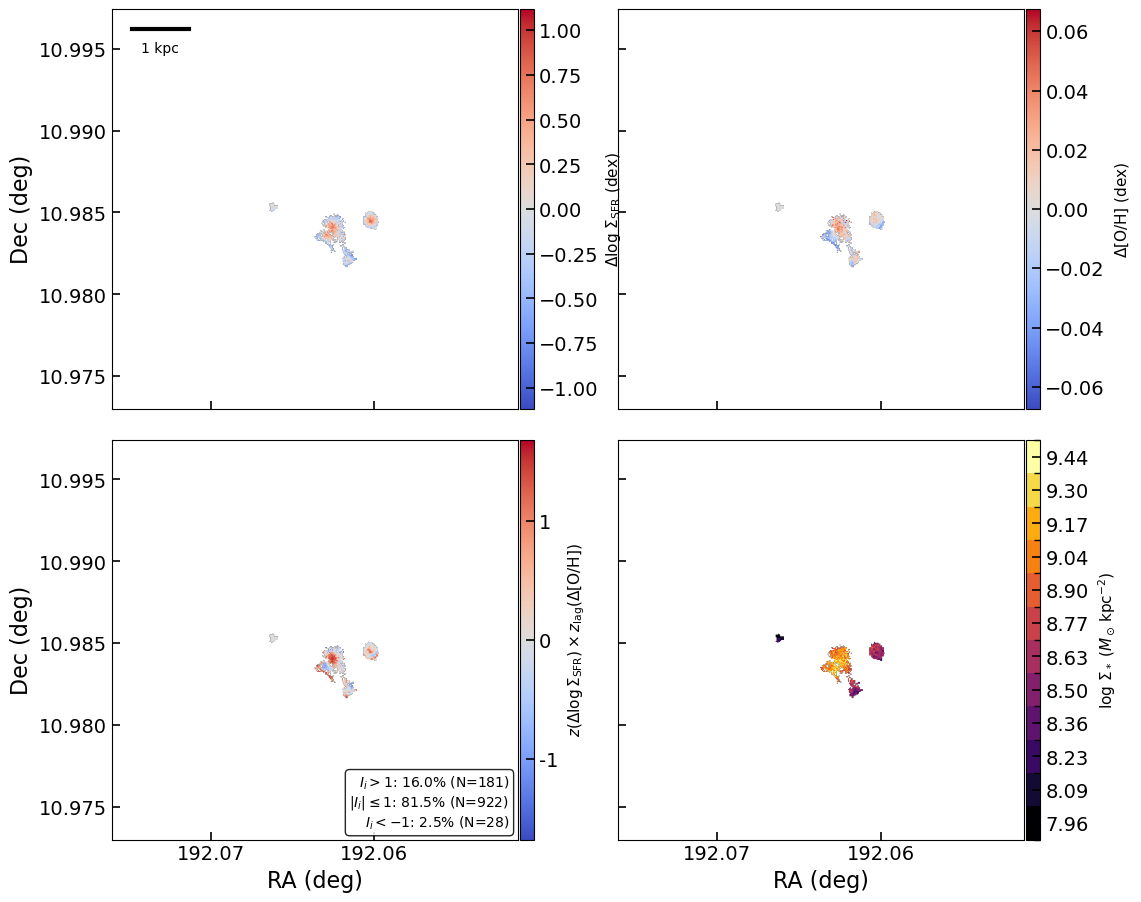

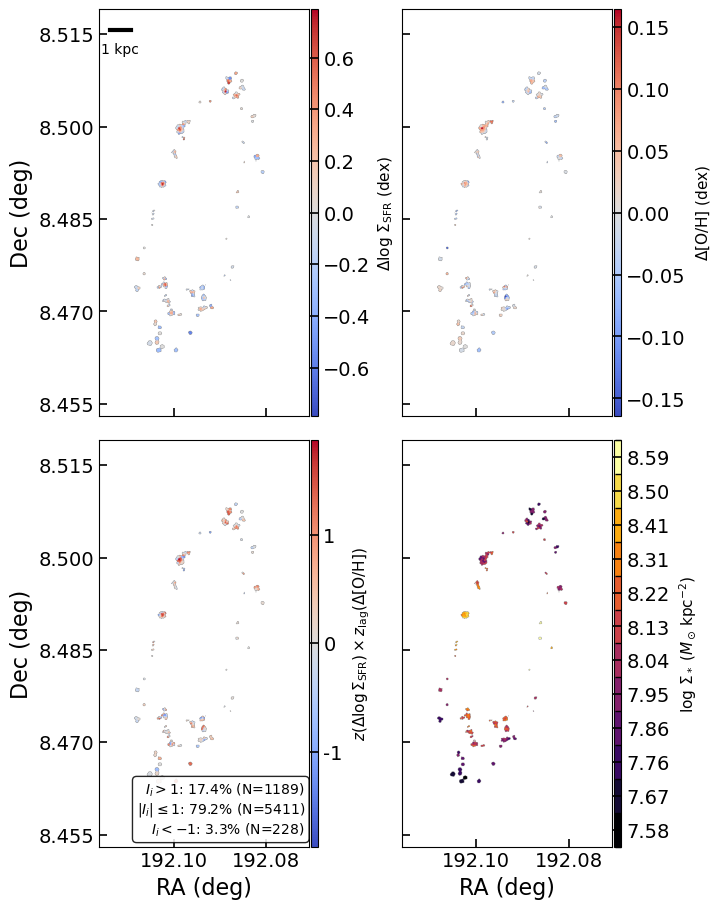

In [2]:
# ------------------------------------------------------------------
# 2x2 Combined figure: offset maps + Moran-like map + binned Σ* map
# ------------------------------------------------------------------
from pathlib import Path
from astropy.io import fits
from astropy.wcs import WCS
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gs_module
from matplotlib.colors import BoundaryNorm, SymLogNorm
import matplotlib.ticker as mticker
from matplotlib.ticker import ScalarFormatter

EW_FILE_SUFFIX = '_proxy_EW_maps.fits'
EW_HDU = 'PROXY_EWHA'
EW_MIN = 6.0


# Loop over all 14 galaxies
galaxies = [
    'IC3392', 'NGC4064', 'NGC4192', 'NGC4293',
    'NGC4298', 'NGC4330', 'NGC4383', 'NGC4396', 'NGC4419',
    'NGC4457', 'NGC4501', 'NGC4522', 'NGC4694', 'NGC4698'
 ]

# ------------------------------------------------------------------
# Define threshold parameter for linear/log colorbar transition and classification
# ------------------------------------------------------------------
threshold = 1  # Values between -threshold and +threshold use linear scale

# ------------------------------------------------------------------
# 1.  Helper: read the required maps
# ------------------------------------------------------------------
def load_maps(gal):
    spatial_path = f'{gal}_SPATIAL_BINNING_maps_extended.fits'
    gas_path = f'{gal}_gas_BIN_maps_extended.fits'
    ew_path = f'{gal}{EW_FILE_SUFFIX}'

    if not (Path(spatial_path).exists() and Path(gas_path).exists() and Path(ew_path).exists()):
        raise FileNotFoundError(f'Required FITS files for {gal} not found.')

    with fits.open(spatial_path) as h_spatial:
        sigM = h_spatial['LOGMASS_SURFACE_DENSITY'].data
        wcs = WCS(h_spatial['LOGMASS_SURFACE_DENSITY'].header)
    with fits.open(gas_path) as h_gas:
        sigSFR = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
        ha_sigma_obs = h_gas['HA6562_SIGMA'].data
        ha_sigma_corr = h_gas['HA6562_SIGMA_CORR'].data if 'HA6562_SIGMA_CORR' in h_gas else None
        if ha_sigma_corr is None:
            raise KeyError(f'{gal}: missing HA6562_SIGMA_CORR in {gas_path}')
        if ha_sigma_corr.shape != ha_sigma_obs.shape:
            raise ValueError(f'{gal}: shape mismatch SIGMA_CORR {ha_sigma_corr.shape} vs SIGMA {ha_sigma_obs.shape}')
        sigma2_intrinsic = ha_sigma_obs**2 - ha_sigma_corr**2
        ha_sigma = np.full_like(ha_sigma_obs, np.nan, dtype=float)
        sigma_ok = np.isfinite(sigma2_intrinsic) & (sigma2_intrinsic > 0)
        ha_sigma[sigma_ok] = np.sqrt(sigma2_intrinsic[sigma_ok])
        if 'O_H_O3N2_M14_HII' in h_gas:
            oh_map = h_gas['O_H_O3N2_M14_HII'].data
            indicator_name = 'O3N2-M14'
        elif 'O_H_O3N2_M13_HII' in h_gas:
            print(f"Warning: O3N2-M14 not available for {gal}; using O3N2-M13 instead.")
            oh_map = h_gas['O_H_O3N2_M13_HII'].data
            indicator_name = 'O3N2-M13'
        else:
            available = [hdu.name for hdu in h_gas]
            raise KeyError(f"No O3N2 metallicity extension (M14/M13) found for {gal}. Available: {available}")
        gas_header = h_gas['LOGSFR_SURFACE_DENSITY_HII'].header
    with fits.open(ew_path) as h_ew:
        if EW_HDU not in h_ew:
            raise KeyError(f"Missing {EW_HDU} in {ew_path}")
        ew_ha = h_ew[EW_HDU].data
    if ew_ha.shape != sigSFR.shape:
        raise ValueError(f"EW shape mismatch for {gal}: {ew_ha.shape} vs {sigSFR.shape}")
    ew_mask = np.isfinite(ew_ha) & (ew_ha > EW_MIN)
    ew_mask = ew_mask & np.isfinite(ha_sigma) & (ha_sigma < 45.0)
    sigSFR = np.where(ew_mask, sigSFR, np.nan)
    oh_map = np.where(ew_mask, oh_map, np.nan)
    return sigM, sigSFR, oh_map, indicator_name, wcs, gas_header

for gal in galaxies:
    sigM, sigSFR, oh_o3n2_map, indicator_name, wcs_full, gas_header = load_maps(gal)

    # Valid pixels across maps
    valid_sfr = np.isfinite(sigSFR)
    valid_oh = np.isfinite(oh_o3n2_map)
    valid_sigM = np.isfinite(sigM)
    valid_all = valid_sfr & valid_oh & valid_sigM

    # ------------------------------------------------------------------
    # 2.  Calculate offset maps (relative to Σ* bin means)
    # ------------------------------------------------------------------
    # Define 12 Σ* bins
    n_bins = 12
    sigmaM_min = np.nanmin(sigM[valid_all])
    sigmaM_max = np.nanmax(sigM[valid_all])
    sigmaM_bin_edges = np.linspace(sigmaM_min, sigmaM_max, n_bins + 1)
    
    # Initialize offset maps
    sfr_offset = np.full_like(sigSFR, np.nan)
    oh_offset = np.full_like(oh_o3n2_map, np.nan)
    
    # Calculate offset for each Σ* bin
    for i in range(n_bins):
        if i == 0:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        elif i == n_bins - 1:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
        else:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        
        if np.sum(bin_mask) > 0:
            # Calculate bin mean and offset within this bin
            sfr_bin_mean = np.mean(sigSFR[bin_mask])
            oh_bin_mean = np.mean(oh_o3n2_map[bin_mask])
            
            sfr_offset[bin_mask] = sigSFR[bin_mask] - sfr_bin_mean
            oh_offset[bin_mask] = oh_o3n2_map[bin_mask] - oh_bin_mean
    
    sfr_offset_max = np.nanmax(np.abs(sfr_offset[valid_all]))
    oh_offset_max = np.nanmax(np.abs(oh_offset[valid_all]))
    
    # Global means for display purposes only
    sfr_mean = np.nanmean(sigSFR[valid_sfr])
    oh_mean = np.nanmean(oh_o3n2_map[valid_oh])

    # ------------------------------------------------------------------
    # 3.  Calculate local bivariate Moran-like map
    # ------------------------------------------------------------------
    def local_bivariate_moran(A, B, valid_mask, neighbourhood='queen'):
        """
        Simple Moran-style local bivariate association between A and B.

        Parameters
        ----------
        A, B : 2D arrays
            Maps (e.g. sfr_offset, oh_offset).
        valid_mask : 2D bool
            True where both maps are valid.
        neighbourhood : {'queen', 'rook'}
            'queen' = 8-connected neighbours, 'rook' = 4-connected.

        Returns
        -------
        I_map : 2D array
            Local bivariate Moran-like statistic (sign & amplitude).
        quad_map : 2D int array
            Quadrant type:
            0 = invalid / no neighbours
            1 = high A, high lag(B)
            2 = low A,  high lag(B)
            3 = low A,  low lag(B)
            4 = high A, low lag(B)
        """
        ny, nx = A.shape
        I_map = np.full_like(A, np.nan, dtype=float)
        quad_map = np.zeros_like(A, dtype=int)

        # standardise A,B on valid pixels only
        Aval = A[valid_mask]
        Bval = B[valid_mask]
        Az = (A - np.nanmean(Aval)) / np.nanstd(Aval)
        Bz = (B - np.nanmean(Bval)) / np.nanstd(Bval)

        if neighbourhood == 'queen':
            offsets = [(-1,-1), (-1,0), (-1,1),
                       ( 0,-1),          ( 0,1),
                       ( 1,-1), ( 1,0), ( 1,1)]
        elif neighbourhood == 'rook':
            offsets = [(-1,0), (0,-1), (0,1), (1,0)]
        else:
            raise ValueError("neighbourhood must be 'queen' or 'rook'")

        for i in range(ny):
            for j in range(nx):
                if not valid_mask[i, j]:
                    continue

                # collect neighbouring Bz values
                neigh_vals = []
                for dy, dx in offsets:
                    ii, jj = i + dy, j + dx
                    if 0 <= ii < ny and 0 <= jj < nx and valid_mask[ii, jj]:
                        neigh_vals.append(Bz[ii, jj])

                if len(neigh_vals) == 0:
                    continue

                lag_B = np.mean(neigh_vals)   # spatial lag of B
                I_val = Az[i, j] * lag_B      # Moran-style product
                I_map[i, j] = I_val

                # quadrant classification (like LISA maps)
                if Az[i, j] >= 0 and lag_B >= 0:
                    quad_map[i, j] = 1  # high A – high B_neigh
                elif Az[i, j] < 0 and lag_B >= 0:
                    quad_map[i, j] = 2  # low A – high B_neigh
                elif Az[i, j] < 0 and lag_B < 0:
                    quad_map[i, j] = 3  # low A – low B_neigh
                else:
                    quad_map[i, j] = 4  # high A – low B_neigh

        return I_map, quad_map

    I_map, quad_map = local_bivariate_moran(sfr_offset, oh_offset, valid_all,
                                            neighbourhood='queen')

    # ------------------------------------------------------------------
    # Calculate statistics for three classes based on threshold
    # ------------------------------------------------------------------
    valid_I = np.isfinite(I_map)
    n_total = np.sum(valid_I)
    n_high = np.sum(I_map[valid_I] > threshold)
    n_mid = np.sum((I_map[valid_I] >= -threshold) & (I_map[valid_I] <= threshold))
    n_low = np.sum(I_map[valid_I] < -threshold)
    pct_high = (n_high / n_total * 100) if n_total > 0 else 0
    pct_mid = (n_mid / n_total * 100) if n_total > 0 else 0
    pct_low = (n_low / n_total * 100) if n_total > 0 else 0

    # ------------------------------------------------------------------
    # 4.  Create binned Σ* map
    # ------------------------------------------------------------------
    sigM_binned_map = np.full_like(sigM, np.nan)
    
    for i in range(n_bins):
        if i == 0:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        elif i == n_bins - 1:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
        else:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        
        # Assign bin center value
        bin_center = (sigmaM_bin_edges[i] + sigmaM_bin_edges[i+1]) / 2
        sigM_binned_map[bin_mask] = bin_center

    # ------------------------------------------------------------------
    # 5.  Prepare coordinate extent
    # ------------------------------------------------------------------
    wcs_celestial = WCS(gas_header).celestial
    y_size, x_size = sigSFR.shape
    x_coords = np.arange(x_size)
    y_coords = np.arange(y_size)
    xx, yy = np.meshgrid(x_coords, y_coords)
    ra, dec = wcs_celestial.pixel_to_world_values(xx, yy)
    extent = [ra.max(), ra.min(), dec.min(), dec.max()]

    # ------------------------------------------------------------------
    # 5b.  Scale bar: 1 kpc for 0.2 arcsec/pixel at 16.5 Mpc
    # ------------------------------------------------------------------
    pix_scale_arcsec = 0.2
    distance_mpc = 16.5
    kpc_arcsec = 206265.0 / (distance_mpc * 1000.0)
    scalebar_length_deg = kpc_arcsec / 3600.0

    def add_scalebar(ax, length_deg, label='1 kpc'):
        x0, x1 = ax.get_xlim()
        x_range = abs(x1 - x0)
        if x_range == 0:
            return
        frac_len = length_deg / x_range
        x_start = 0.05
        y_start = 0.95
        x_end = x_start + frac_len
        line, = ax.plot([x_start, x_end], [y_start, y_start], transform=ax.transAxes,
                        color='k', lw=3, clip_on=False)
        line.set_in_layout(False)
        txt = ax.text((x_start + x_end) / 2, y_start - 0.03, label,
                      transform=ax.transAxes, ha='center', va='top', color='k')
        txt.set_in_layout(False)

    # ------------------------------------------------------------------
    # 6.  2x2 figure: shared axes, equal aspect preserved, colorbars glued to axes
    # ------------------------------------------------------------------
    from mpl_toolkits.axes_grid1 import make_axes_locatable

    # Auto-derive a reasonable figsize from the map extent
    dx = abs(extent[1] - extent[0])   # RA span
    dy = abs(extent[3] - extent[2])   # Dec span
    data_ratio = (dx / dy) if dy > 0 else 1.0  # width / height

    panel_h = 4.2   # inches per panel height (tune once)
    panel_w = panel_h * data_ratio
    cbar_w = 0.35   # inches per colorbar (tune once)

    W = 2 * panel_w + 2 * cbar_w + 1.2
    H = 2 * panel_h + 0.8

    fig, axs = plt.subplots(
        2, 2, figsize=(W, H), sharex=True, sharey=True
    )

    # Make space for the appended colorbars (right margin matters)
    fig.subplots_adjust(
        left=0.07, right=0.96, bottom=0.07, top=0.98,
        wspace=0.20, hspace=0.06
    )

    ax1, ax2 = axs[0, 0], axs[0, 1]
    ax3, ax4 = axs[1, 0], axs[1, 1]

    def add_cbar(ax, im, label, size="3.5%", pad=0.02, labelpad=6, labelsize=11):
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size=size, pad=pad)
        cbar = fig.colorbar(im, cax=cax)
        cbar.set_label(label, fontsize=labelsize, labelpad=labelpad)
        return cbar

    # --- Ticks / formatting (readable RA, no +1.834e2)
    for ax in (ax1, ax2, ax3, ax4):
        ax.xaxis.set_major_locator(mticker.MaxNLocator(3))
        ax.yaxis.set_major_locator(mticker.MaxNLocator(5))
        ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

    # Hide inner tick labels
    plt.setp(ax1.get_xticklabels(), visible=False)
    plt.setp(ax2.get_xticklabels(), visible=False)
    plt.setp(ax2.get_yticklabels(), visible=False)
    plt.setp(ax4.get_yticklabels(), visible=False)

    # Axis labels (outer only)
    ax3.set_xlabel("RA (deg)", fontsize=16)
    ax4.set_xlabel("RA (deg)", fontsize=16)
    ax1.set_ylabel("Dec (deg)", fontsize=16)
    ax3.set_ylabel("Dec (deg)", fontsize=16)

    # ---- Panel 1: SFR offset
    im_sfr = ax1.imshow(
        np.ma.masked_invalid(sfr_offset),
        origin="lower", cmap="coolwarm",
        extent=extent, vmin=-sfr_offset_max, vmax=sfr_offset_max,
        aspect="equal"
    )
    add_scalebar(ax1, scalebar_length_deg, label="1 kpc")
    add_cbar(ax1, im_sfr, r'$\Delta\log\,\Sigma_{\mathrm{SFR}}$ (dex)', labelpad=4)

    # ---- Panel 2: OH offset
    im_oh = ax2.imshow(
        np.ma.masked_invalid(oh_offset),
        origin="lower", cmap="coolwarm",
        extent=extent, vmin=-oh_offset_max, vmax=oh_offset_max,
        aspect="equal"
    )
    add_cbar(ax2, im_oh, r'$\Delta$[O/H] (dex)')

    # ---- Panel 3: Moran-like
    vI = np.nanmax(np.abs(I_map))
    norm = SymLogNorm(linthresh=threshold, linscale=1.0, vmin=-vI, vmax=vI, base=10)

    imI = ax3.imshow(
        np.ma.masked_invalid(I_map),
        origin="lower", cmap="coolwarm",
        extent=extent, norm=norm,
        aspect="equal"
    )
    cbarI = add_cbar(
        ax3, imI,
        r'$z(\Delta\log\Sigma_{\rm SFR}) \times z_{\rm lag}(\Delta{\rm [O/H]})$'
    )

    # Keep your symmetric-log ticks logic
    max_pow = int(np.floor(np.log10(vI))) if vI > 0 else 0
    pos_ticks = [10**k for k in range(0, max_pow + 1) if 10**k <= vI]
    pos_ticks_filtered = [p for p in pos_ticks if p != threshold]
    neg_ticks_filtered = [-p for p in reversed(pos_ticks_filtered)]
    ticks = sorted(set(neg_ticks_filtered + [-threshold, 0.0, threshold] + pos_ticks_filtered))
    cbarI.set_ticks(ticks)
    cbarI.set_ticklabels([f"{t:g}" for t in ticks])

    legend_text = (
        rf'$I_i > {threshold}$: {pct_high:.1f}% (N={n_high})'
        '\n' + rf'$|I_i| \leq {threshold}$: {pct_mid:.1f}% (N={n_mid})'
        '\n' + rf'$I_i < -{threshold}$: {pct_low:.1f}% (N={n_low})'
    )
    ax3.text(
        0.98, 0.02, legend_text, transform=ax3.transAxes,
        fontsize=10, va="bottom", ha="right",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.85)
    )

    # ---- Panel 4: binned Σ*
    cmap_discrete = plt.cm.inferno
    norm_discrete = BoundaryNorm(sigmaM_bin_edges, cmap_discrete.N)

    im_sigM_binned = ax4.imshow(
        np.ma.masked_invalid(sigM_binned_map),
        origin="lower", cmap=cmap_discrete, norm=norm_discrete,
        extent=extent,
        aspect="equal"
    )
    cbar_binned = add_cbar(
        ax4, im_sigM_binned,
        r'$\log\,\Sigma_*\;(M_\odot\,\mathrm{kpc}^{-2})$'
    )

    bin_centers = [(sigmaM_bin_edges[i] + sigmaM_bin_edges[i+1]) / 2 for i in range(n_bins)]
    cbar_binned.set_ticks(bin_centers)
    cbar_binned.set_ticklabels([f"{bc:.2f}" for bc in bin_centers])

    fig.savefig(f'Moran_MAUVE14/{gal}_correlation_map_moran_EW.png', dpi=600, bbox_inches="tight", pad_inches=0.02)
    fig.savefig(f'Moran_MAUVE14/{gal}_correlation_map_moran_EW.pdf', bbox_inches="tight", pad_inches=0.02)
    plt.show()